In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
u_train = pd.read_parquet("../../datasets/train-test-split/user_train.parquet")
u_test = pd.read_parquet("../../datasets/train-test-split/user_test.parquet")
e_train = pd.read_parquet("../../datasets/train-test-split/explanation_train.parquet")
e_test = pd.read_parquet("../../datasets/train-test-split/explanation_test.parquet")
i_train = pd.read_parquet("../../datasets/train-test-split/item_train.parquet")
i_test = pd.read_parquet("../../datasets/train-test-split/item_test.parquet")

y_train = pd.read_parquet("../../datasets/train-test-split/rating_train.parquet")
y_test = pd.read_parquet("../../datasets/train-test-split/rating_test.parquet")

In [25]:
from tensorflow import keras

model = keras.models.load_model("../../models/mlp_without_overview/1/simple_mlp_model.keras")

In [27]:
predictions = model.predict([u_test, i_test])

6030/6030 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [28]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions)) 

RMSE: 1.1145427316180938
MAE: 0.9298110604286194
R2 Score: -9.167194366455078e-05


In [29]:
predictions.shape

(192949, 1)

In [30]:
y_test[0].shape

(192949,)

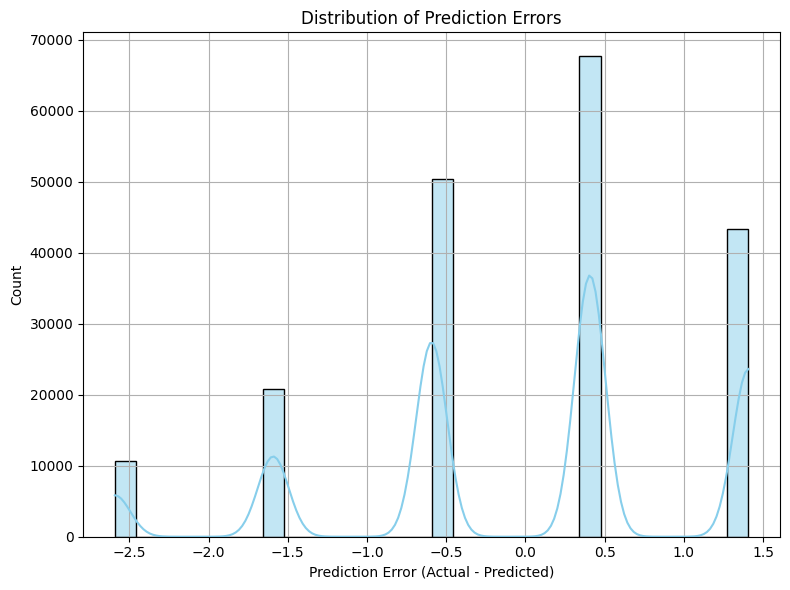

In [31]:
import seaborn as sns
# or y_test.ravel()

flatter_predictions = predictions.flatten()
errors = y_test[0] - flatter_predictions

# Plot distribution of prediction errors
plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=30, kde=True, color="skyblue")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_error_distribution.png")  # optional
plt.show()

In [21]:
y_test

,0
0,4.0
1,2.0
2,5.0
3,4.0
4,5.0
...,...
192944,2.0
192945,3.0
192946,4.0
192947,4.0


6030/6030 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


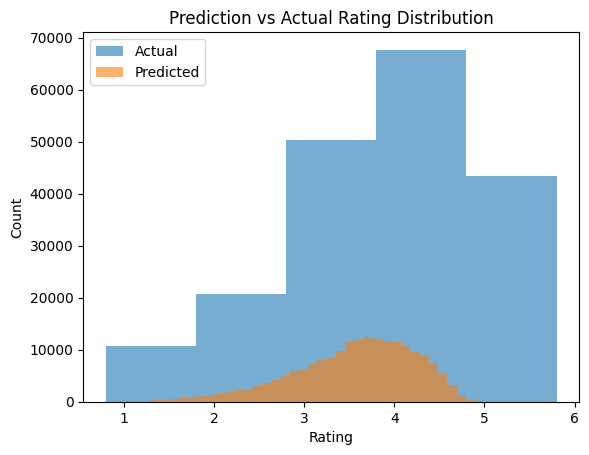

In [ ]:


y_pred = model.predict([u_test.values, i_test.values, e_test.values]).flatten()


y_true = y_test.values.flatten()


plt.figure()

bins_true = np.arange(0.8, 5 + 1, 1)
plt.hist(y_true, bins=bins_true, label="Actual", alpha=0.6)


bins_pred = np.linspace(1, 5, 40)
plt.hist(y_pred, bins=bins_pred, label="Predicted", alpha=0.6)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Prediction vs Actual Rating Distribution")
plt.legend()
plt.show()

In [14]:
def distribution_plot( dataset: pd.DataFrame,title:str, x_label:str, y_label:str, figsize: set = (10, 6)):
    plt.figure(figsize=figsize)
    sns.histplot(dataset, bins=50, kde=True, color="salmon")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

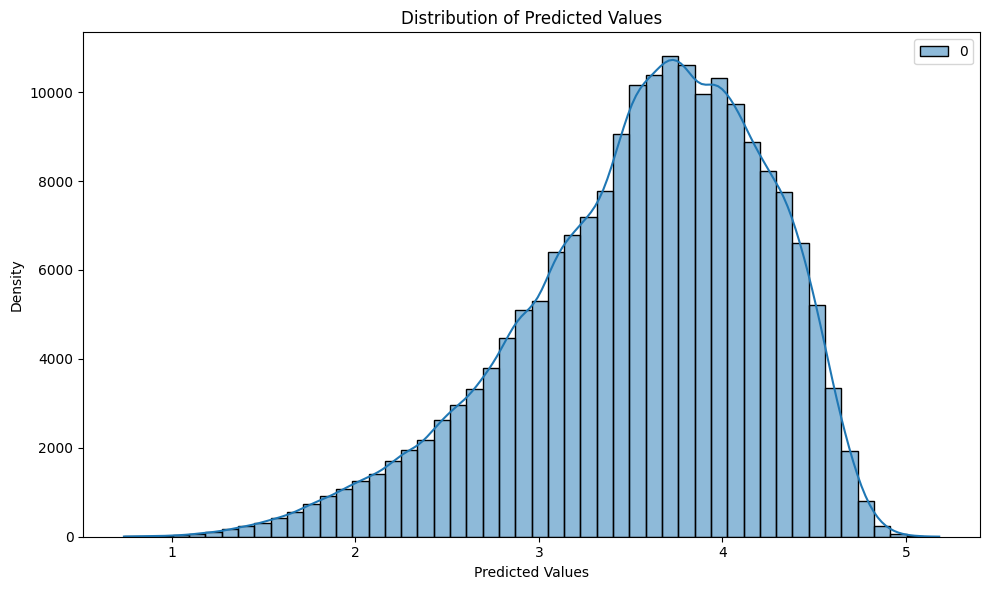

In [17]:
distribution_plot(predictions, "Distribution of Predicted Values", "Predicted Values", "Density")

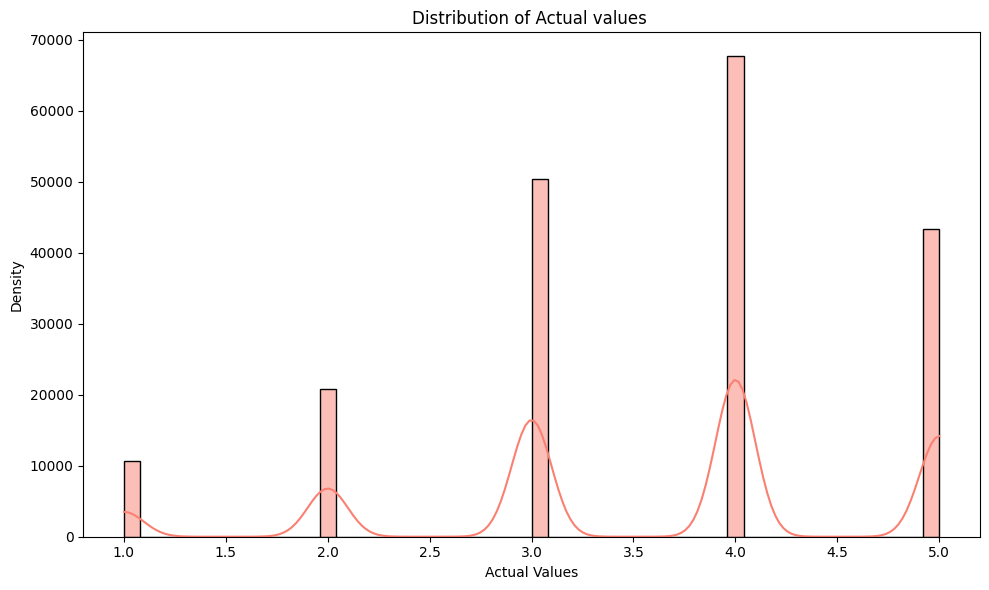

In [20]:
y_true = y_test.values.flatten()
distribution_plot(y_true, "Distribution of Actual values ", "Actual Values", "Density")

In [15]:
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult",
]
numeric_cols = ["popularity", "vote_average", "vote_count", "original_langage_encoded"]
user_cols = [
    "UserID",
    "Age",
    "occupation_encoded",
    "Zipcode_endcoded",
    "Gender_M",
    "Gender_F",
]

In [24]:
u_test.values[:100]

array([[2.944e+03, 1.800e+01, 4.000e+00, 1.600e+03, 0.000e+00, 1.000e+00],
       [3.645e+03, 3.500e+01, 1.700e+01, 3.296e+03, 1.000e+00, 0.000e+00],
       [5.625e+03, 2.500e+01, 1.000e+00, 5.200e+01, 1.000e+00, 0.000e+00],
       [2.060e+03, 1.000e+00, 1.000e+00, 1.634e+03, 1.000e+00, 0.000e+00],
       [4.784e+03, 3.500e+01, 6.000e+00, 1.601e+03, 0.000e+00, 1.000e+00],
       [4.279e+03, 2.500e+01, 1.600e+01, 1.390e+03, 1.000e+00, 0.000e+00],
       [3.829e+03, 2.500e+01, 1.000e+00, 8.880e+02, 0.000e+00, 1.000e+00],
       [2.408e+03, 4.500e+01, 1.000e+00, 4.200e+01, 0.000e+00, 1.000e+00],
       [3.272e+03, 3.500e+01, 0.000e+00, 3.650e+02, 1.000e+00, 0.000e+00],
       [3.321e+03, 3.500e+01, 1.000e+00, 3.190e+03, 1.000e+00, 0.000e+00],
       [2.041e+03, 2.500e+01, 2.000e+01, 9.400e+02, 0.000e+00, 1.000e+00],
       [3.970e+03, 2.500e+01, 2.000e+00, 1.780e+02, 0.000e+00, 1.000e+00],
       [5.684e+03, 1.800e+01, 1.600e+01, 3.057e+03, 1.000e+00, 0.000e+00],
       [2.820e+03, 3.500e

In [18]:
%pip install scikeras